# Assignment 4: Applying Methods and Techniques for Data Imputation and Semi-Supervised Learning

For the Module 4 programming assignment, you will discover how supervised and unsupervised learning can be used in conjunction with each other for important data science tasks. You will begin with data imputation and move on to an example of conducting semi-supervised learning with label propagation.

* First, you are going to test out and compare several different imputation strategies to deal with missing values of the *features* in a dataset.

* Second, you will do label propagation on a partially-labelled dataset of mushrooms to determine their edibility and compute the accuracy of the label propagation prediction (i.e. the accuracy of mushrooms being labeled as edible/unedible). 


In [1]:
# First import some necessary libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

All import statements are provided for you- please do not import other libraries in your own code.

# Task 1: Data imputation

Machine learning is used throughout the food industry, including in large-scale fruit and vegetable processing to automatically detect and filter acceptable vs unacceptable items for consumers. In this task, we're going to take a look at a simple version of a dataset that might be used to train such classification systems.

We'll work with a database about apples: each row of the table corresponds to an observed apple, and the columns corresponding to different features of an apple such as its size, color, shape, etc. There is also a column that contains a binary label marking each observed apple as "good" or "bad" for consumption.

Real-world datasets often have missing data, so the goal for this task is for you to get some practice using the imputation methods in Module 4 to infer missing values in a dataset. Please refer to the module 4 reading, notebook and data imputation lecture for examples of code on how to use an Imputer class (including optionally tied to a Regression class via a pipeline object). 

Our original apples dataset doesn't have any missing data, so we produce a noisy version of the original dataset for you to work with that has random features missing for random apples. Missing data in a cell is represented by `NaN`. The provided function `create_copy_with_missing_values` is the code that produces the noisy version of the apple dataset.

Your goal for Task 1 is to compare the effectiveness of different imputer strategies for filling in the missing data cells (`NaN`) in the noisy apple dataset. We're going to do a *task-based* evaluation of imputer effectiveness, where the task is correctly predicting an apple's "goodness" score: a superior imputation strategy should give a higher prediction score on test data.

For all the subtasks below, the array `X_missing` contains the noisy dataset features of the apples, such as size, shape, etc. and `y_missing` contains the binary good/bad label for each apple in the noisy dataset.

In [2]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.datasets import load_diabetes
def create_copy_with_missing_values(X, y, missing_rate=0.75):
    n_samples, n_features = X.shape

    n_missing_samples = int(n_samples * missing_rate)

    # now pick which rows, columns should correspond to the missing samples
    missing_instances = rng.choice(n_samples, size=n_missing_samples, replace=False)
    missing_features = rng.randint(0, n_features, n_missing_samples)

    X_missing = X.copy()
    y_missing = y.copy()

    X_missing[missing_instances, missing_features] = np.nan

    return X_missing, y_missing

rng = np.random.RandomState(42)
CV_SPLITS = 7
missing_rate = 0.70
regressor = RandomForestRegressor(random_state=42)
x_labels = [
    "Simple imputation: always zero",
    "Removing Rows with empty values",
    "k-NN imputation",
        "Full data",
]

score_type = "r2"
n_entries = len(x_labels)
mses_dataset = np.zeros(n_entries)
stds_dataset = np.zeros(n_entries)

# Load the apple dataset from the CSV file
apple_data = pd.read_csv('./assets/apple_quality.csv')
apple_data = apple_data.head(100)

# Extract features (X) and target variable (y) from the dataset
X_full = apple_data.drop(columns=['Quality', 'A_id']).values
y_full = apple_data['Quality'].values
X_full = X_full.astype(np.float64)

label_mapping = {'good': 1, 'bad': 0}

# Convert labels in y_full using the mapping function
y_full = np.array([label_mapping[label] for label in y_full])

print(X_full)
print(y_full)

X_missing, y_missing = create_copy_with_missing_values(
    X_full, y_full, missing_rate=missing_rate
)

def get_scores_using_imputer(imputer):
    estimator = make_pipeline(imputer, regressor)
    impute_scores = cross_val_score(
        estimator, X_missing, y_missing, scoring=score_type, cv=CV_SPLITS
    )
    # print(impute_scores)
    return impute_scores

[[-3.97004852 -2.51233638  5.34632961 -1.01200871  1.84490036  0.3298398
  -0.49159048]
 [-1.19521719 -2.83925653  3.66405876  1.58823231  0.8532858   0.86753008
  -0.72280937]
 [-0.29202386 -1.35128199 -1.73842916 -0.34261593  2.83863551 -0.03803333
   2.62163647]
 [-0.65719577 -2.27162661  1.32487385 -0.09787472  3.63797049 -3.41376134
   0.79072322]
 [ 1.36421682 -1.29661188 -0.38465821 -0.55300577  3.03087435 -1.30384943
   0.50198404]
 [-3.42539975 -1.4090822  -1.9135112  -0.55577486 -3.85307147  1.91461592
  -2.98152317]
 [ 1.33160574  1.63595571  0.87597424 -1.67779794  3.10634445 -1.84741673
   2.41417051]
 [-1.9954621  -0.42895848  1.53064358 -0.74297168  0.158834    0.97443786
  -1.47012507]
 [-3.86763223 -3.73451358  0.98642907 -1.20765455  2.29287292  4.08092079
  -4.87190476]
 [-0.72798271 -0.44282035 -4.09222283  0.59751292  0.39371426  1.62085677
   2.18560772]
 [-2.69933629 -1.32950699 -1.41850685 -0.62554577  2.37107437  3.40316452
  -2.81080817]
 [ 2.45095984 -0.56417

# Task 1a: Simple imputation by replacing with zero

One strategy to deal with missing values is when we come across with an apple that might have a missing attribute such as "weight" or "size", to just simply replace that missing value with zero. In general, as we covered in the lecture, this is a risky strategy that can introduce significant bias into the data if the true values are often non-zero.  However, we'll use this very basic strategy as a baseline against which to compare the other imputation strategies.

In this subtask, you will be writing a function that first creates a SimpleImputer with the following arguments:

`missing_values = np.nan, add_indicator=True, strategy = "constant", fill_value = 0`.

Then pass this simple imputer object as input to the provided `get_scores_using_imputer` function defined above to obtain the mean and standard deviation of the imputation scores, and return both of those numbers from your function, in that order. The mean and standard deviation can be obtained by calling `.mean()` and `.std()` respectively on the object returned by the `get_scores_using_imputer` function.


In [3]:
task_id = '1a'


In [4]:
def task_1a_solution():

    mean = 0
    std = 0
    imputer = None
    imputer = SimpleImputer(missing_values=np.nan, add_indicator=True,
                            strategy="constant", fill_value=0)
    scores = get_scores_using_imputer(imputer)
    mean = scores.mean()
    std = scores.std()

    return mean, std

In [5]:
print(f"Task {task_id} - AG tests")
stu_ans = task_1a_solution()


print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, tuple
), f"Task {task_id}: Your function should return a tuple "




del stu_ans

Task 1a - AG tests
Task 1a - your answer:
(0.14868134920634932, 0.19039241486251157)


# Task 1b: Removing rows with missing values

Another strategy to deal with missing values is to simply remove rows with missing values. 

In the function, first use `np.isnan` on `X_missing` to find the indices of rows with any missing values, and then use that result to make new versions of `X_missing` and `y_missing` that don't contain those rows. We'll call these new versions `X_cleaned` and `y_cleaned`.


Next, call `cross_val_score` as in the `get_scores_using_imputer` utility code above, but this time, you will be passing in the provided estimator `new_pipeline`, and `X_cleaned` and `y_cleaned` instead of `X_missing` and `y_missing`. All other arguments will remain the same. As in Task 1a, you then call `.mean()` and `.std()` on the object returned by `cross_val_score` to obtain the mean and standard deviation of the imputation scores, and return both of those numbers from your function, in that order.

In [6]:
task_id = '1b'


In [7]:
def task_1b_solution():

    mean = 0
    std = 0
    new_pipeline = make_pipeline(regressor)
    keep_rows = ~np.isnan(X_missing).any(axis=1)
    X_cleaned = X_missing[keep_rows]
    y_cleaned = y_missing[keep_rows]

    scores = cross_val_score(new_pipeline, X_cleaned, y_cleaned,
                             scoring=score_type, cv=CV_SPLITS)
    mean = scores.mean()
    std = scores.std()

    return mean, std

In [8]:
print(f"Task {task_id} - AG tests")
stu_ans = task_1b_solution()


print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, tuple
), f"Task {task_id}: Your function should return a tuple "




del stu_ans

Task 1b - AG tests
Task 1b - your answer:
(0.15484047619047622, 0.3114090835063252)


# Task 1c: Using k-NN imputation

A third strategy for imputing missing values is to use a more refined imputation method: k-NN imputation. This approach uses the k-nearest neighbors algorithm to find similar nearby data points and then estimate the missing value using the mean or median of the values of that feature from the nearest neighbor points.

Start by creating a KNNImputer object with `missing_values=np.nan` and `add_indicator=True`. (We covered the purpose of the `add_indicator` option in the imputation lecture.)

Then, as in Task 1a, use the KNNImputer objects as the input argument to the provided `get_scores_using_imputer` function to obtain the mean and standard deviation scores that are output from the imputer, and return both of those numbers from your function, in that order.

In [9]:
task_id = '1c'





In [10]:
def task_1c_solution():

    mean = 0
    std = 0

    imputer = KNNImputer(missing_values=np.nan, add_indicator=True)
    scores = get_scores_using_imputer(imputer)
    mean = scores.mean()
    std = scores.std()

    return mean, std

In [11]:
print(f"Task {task_id} - AG tests")
stu_ans = task_1c_solution()


print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, tuple
), f"Task {task_id}: Your function should return a tuple "




del stu_ans

Task 1c - AG tests
Task 1c - your answer:
(0.2222202777777778, 0.12328810847604282)


With all three imputation methods implemented, run the code below to compare the prediction effectiveness of the different strategies. Which imputation strategy resulted in the best mean prediction performance?

[0.14868135 0.15484048 0.22222028 0.28818417] [0.19039241 0.31140908 0.12328811 0.18864577]


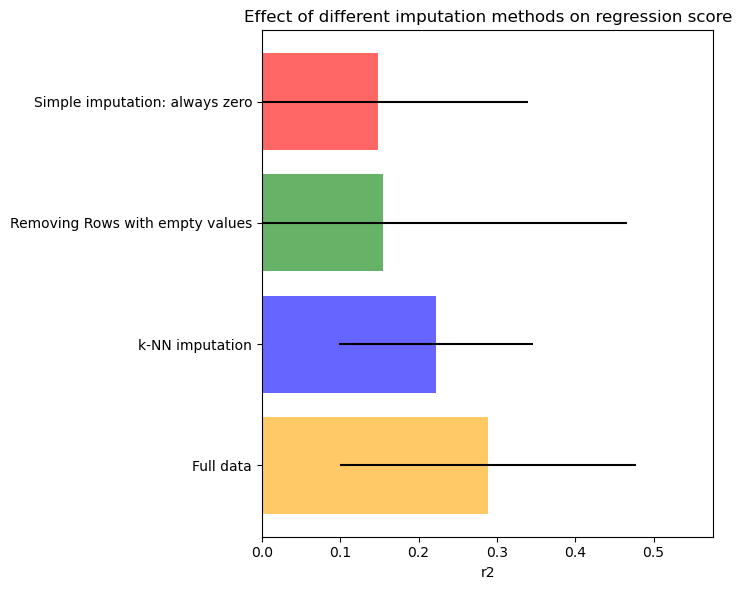

In [12]:
def get_full_score():
    full_scores = cross_val_score(regressor, X_full, y_full, scoring=score_type, cv=CV_SPLITS)
    return full_scores.mean(), full_scores.std()


### Plot results
### This plotting code adapted from scikit-learn impute documentation.
mses_dataset[0], stds_dataset[0] = task_1a_solution()
mses_dataset[1], stds_dataset[1] = task_1b_solution()
mses_dataset[2], stds_dataset[2] = task_1c_solution()
mses_dataset[3], stds_dataset[3] = get_full_score()

n_bars = n_entries
xval = np.arange(n_bars)
colors = ["r", "g", "b", "orange"]

plt.figure(figsize=(12, 6))
ax1 = plt.subplot(121)

ax1.set_title("Effect of different imputation methods on regression score")
ax1.set_xlim(left=np.min(mses_dataset) * 0, right=np.max(mses_dataset) * 2)
ax1.set_yticks(xval)
ax1.set_xlabel(score_type)
ax1.invert_yaxis()
ax1.set_yticklabels(x_labels)

for j in xval:
    ax1.barh(
        j,
        mses_dataset[j],
        xerr=stds_dataset[j],
        color=colors[j],
        alpha=0.6,
        align="center",
    )

print(mses_dataset, stds_dataset)

plt.tight_layout()

# Task 2: Label Propagation
(40 points)

Unluckily, you have become stranded on a desert island. But luckily, there is food on the island in the form of mushrooms, which grow everywhere. Also luckily, whatever hapless individual was stranded here before you kept a record of every type of mushroom growing on this island with features such as cap shape, odor, and most importantly, whether or not they are edible or poisonous. Unluckily, however, some of the stickers labelling the mushrooms as edible or poisonous have eroded over time! Fortunately, you managed to save your solar-powered laptop and have it with you, so to make the mushrooms (and yourself) last as long as possible before help arrives, you decide to do label propagation on this damaged mushrooms dataset to determine the edibility of unlabeled mushrooms. You only want to eat mushrooms labeled by label propagation as edible if you're confident that your algorithm is accurate. Your task is to calculate the effectiveness of the label propagation algorithm on your mushroom data by computing the downstream accuracy of a classifier trained with the inferred labels, i.e. the fraction of mushrooms being correctly labeled as edible/unedible.  The classifier in this case used to predict a mushroom's edibility will be a linear support vector machine (SVC).

To use label propagation, as explained in the lecture, we first need to define the distance measure to be used on pairs of items. Our items are mushrooms, which are represented using a mixture of different feature types (e.g. categorical, numeric). In this case, a very handy distance measure for mixed-type features is the [Gower distance measure](https://en.wikipedia.org/wiki/Gower%27s_distance). We provide code to compute Gower's distance below. 

To accomplish this, do the following:

- Run the preamble code below.  This will, among other things, create a train-test split of the data and set variables `X_train`, `X_test`, `y_train`, `y_test`. 
- As provided in the solution preamble, you call `get_mangled_label_dataset` with the specified parameters, on `X_train` to produce `X_train_complete`, and `y_train_complete_missing`, which represent a simulated dataset with missing labels.
- Perform label propagation by first creating a [LabelSpreading] object (https://scikit-learn.org/stable/modules/generated/sklearn.semi_supervised.LabelSpreading.html) object with `kernel='knn', n_neighbors=9, max_iter=30, tol=0.001`
- Then fit the label propagation model using `X_train_complete`, and `y_train_complete_missing`.
- Use `.predict()` to obtain the predicted labels that fill in the missing `y` label values. 
- Then, create a support vector classifier **using the [SVC] class (https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)** with default parameters and fit the classifier using the complete training set with inferred labels from the previous step.
- Compute the accuracy of the SVC classifier on the test set (`y_test` has the gold standard labels, to be compared against the predicted labels from the SVC classifier for the items in `X_test`)
- Your function should return a single float: the accuracy of the SVC classifier.

Note: the two cells below contain very long preamble code. You may want to minimize them to make it easier to work between the instructions and your solution code.


In [13]:
"""


"""
from sklearn import datasets
from sklearn.semi_supervised import LabelPropagation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


def get_mangled_label_dataset(X_train, y_train, frac_0, frac_1):
    """
    This function takes a dataset and label set as input, and returns the following:
      - The X features of the subset of instances that had intact labels
      - The y labels of the subset of instances that had intact labels
      - The X features of the complete training set
      - The y labels of the complete training set WITH DESTROYED LABELS according to the assignment specifications.

    input parameters frac_0, frac_1 indicate the probability you want to mangle class 0 and class 1 labels
    respectively.
    """

    rng = np.random.RandomState(0)

    X_train_0 = X_train[y_train == 0]
    y_train_0 = y_train[y_train == 0]

    X_train_1 = X_train[y_train == 1]
    y_train_1 = y_train[y_train == 1]

    X_train_complete = np.vstack((X_train_0, X_train_1))
    y_train_complete = np.concatenate((y_train_0, y_train_1))

    random_unlabeled_points_0 = rng.rand(len(y_train_0)) < frac_0
    random_unlabeled_points_1 = rng.rand(len(y_train_1)) < frac_1
    random_unlabeled_points = np.concatenate(
        (random_unlabeled_points_0, random_unlabeled_points_1)
    )

    random_labeled_points_0 = np.logical_not(random_unlabeled_points_0)
    random_labeled_points_1 = np.logical_not(random_unlabeled_points_1)

    labeled_subset_X_train_0 = X_train_0[random_labeled_points_0]
    labeled_subset_X_train_1 = X_train_1[random_labeled_points_1]
    labeled_subset_y_train_0 = y_train_0[random_labeled_points_0]
    labeled_subset_y_train_1 = y_train_1[random_labeled_points_1]

    labeled_subset_X_train = np.vstack(
        (labeled_subset_X_train_0, labeled_subset_X_train_1)
    )
    labeled_subset_y_train = np.concatenate(
        (labeled_subset_y_train_0, labeled_subset_y_train_1)
    )

    labels_train_with_destroyed = np.copy(y_train_complete)
    labels_train_with_destroyed[random_unlabeled_points] = -1

    return (
        labeled_subset_X_train,
        labeled_subset_y_train,
        X_train_complete,
        labels_train_with_destroyed,
    )


In [14]:

from scipy.spatial import distance
from sklearn.utils import validation
from sklearn.metrics import pairwise
from scipy.sparse import issparse

# The following functions are provided by Marcelo Beckmann and currently are part of the scikit-learn
# github repository but have not yet been officially released.


# This is a utility function used by gower_distances below.
def check_pairwise_arrays(X, Y, precomputed=False, dtype=None):
    X, Y, dtype_float = pairwise._return_float_dtype(X, Y)

    warn_on_dtype = dtype is not None
    estimator = "check_pairwise_arrays"
    if dtype is None:
        dtype = dtype_float

    if Y is X or Y is None:
        X = Y = validation.check_array(
            X, accept_sparse="csr", dtype=dtype, estimator=estimator
        )
    else:
        X = validation.check_array(
            X, accept_sparse="csr", dtype=dtype, estimator=estimator
        )
        Y = validation.check_array(
            Y, accept_sparse="csr", dtype=dtype, estimator=estimator
        )

    if precomputed:
        if X.shape[1] != Y.shape[0]:
            raise ValueError(
                "Precomputed metric requires shape "
                "(n_queries, n_indexed). Got (%d, %d) "
                "for %d indexed." % (X.shape[0], X.shape[1], Y.shape[0])
            )
    elif X.shape[1] != Y.shape[1]:
        raise ValueError(
            "Incompatible dimension for X and Y matrices: "
            "X.shape[1] == %d while Y.shape[1] == %d" % (X.shape[1], Y.shape[1])
        )

    return X, Y


# gower_distances: see header below for details.
#
# For purposes of this assignment you can simply call it like this on a dataset X (n instances):
# D = gower_distances(X)
#
# which results an n x n distance matrix.
#
# Source: M. Beckmann  https://github.com/scikit-learn/scikit-learn/pull/9555


def gower_distances(X, Y=None, feature_weight=None, categorical_features=None):
    """Computes the gower distances between X and Y

    Gower is a similarity measure for categorical, boolean and numerical mixed
    data.


    Parameters
    ----------
    X : array-like, or pandas.DataFrame, shape (n_samples, n_features)

    Y : array-like, or pandas.DataFrame, shape (n_samples, n_features)

    feature_weight :  array-like, shape (n_features)
        According the Gower formula, feature_weight is an attribute weight.

    categorical_features: array-like, shape (n_features)
        Indicates with True/False whether a column is a categorical attribute.
        This is useful when categorical atributes are represented as integer
        values. Categorical ordinal attributes are treated as numeric, and must
        be marked as false.

        Alternatively, the categorical_features array can be represented only
        with the numerical indexes of the categorical attribtes.

    Returns
    -------
    similarities : ndarray, shape (n_samples, n_samples)

    Notes
    ------
    The non-numeric features, and numeric feature ranges are determined from X and not Y.
    No support for sparse matrices.

    """

    if issparse(X) or issparse(Y):
        raise TypeError("Sparse matrices are not supported for gower distance")

    y_none = Y is None

    # It is necessary to convert to ndarray in advance to define the dtype
    if not isinstance(X, np.ndarray):
        X = np.asarray(X)

    # this is necessary as strangelly the validator is rejecting
    #  numeric arrays with NaN
    # array_type = np.object

    # array_type = object replaces above due to deprecation of
    # np.object.
    array_type = object

    if np.issubdtype(X.dtype, np.number) and (
        np.isfinite(X.sum()) or np.isfinite(X).all()
    ):
        array_type = type(np.zeros(1, X.dtype).flat[0])

    X, Y = check_pairwise_arrays(X, Y, precomputed=False, dtype=array_type)

    n_rows, n_cols = X.shape

    if categorical_features is None:
        categorical_features = np.zeros(n_cols, dtype=bool)
        for col in range(n_cols):
            # In numerical columns, None is converted to NaN,
            # and the type of NaN is recognized as a number subtype
            if not np.issubdtype(type(X[0, col]), np.number):
                categorical_features[col] = True
    else:
        categorical_features = np.array(categorical_features)

    # if categorical_features.dtype == np.int32:
    # np.int deprecated
    # if np.issubdtype(categorical_features.dtype, np.int):

    if np.issubdtype(categorical_features.dtype, np.int64):
        new_categorical_features = np.zeros(n_cols, dtype=bool)
        new_categorical_features[categorical_features] = True
        categorical_features = new_categorical_features

    # print(categorical_features)

    # Categorical columns
    X_cat = X[:, categorical_features]

    # Numerical columns
    X_num = X[:, np.logical_not(categorical_features)]
    ranges_of_numeric = None
    max_of_numeric = None

    # Calculates the normalized ranges and max values of numeric values
    _, num_cols = X_num.shape
    ranges_of_numeric = np.zeros(num_cols)
    max_of_numeric = np.zeros(num_cols)
    for col in range(num_cols):
        col_array = X_num[:, col].astype(np.float32)
        max = np.nanmax(col_array)
        min = np.nanmin(col_array)

        if np.isnan(max):
            max = 0.0
        if np.isnan(min):
            min = 0.0
        max_of_numeric[col] = max
        ranges_of_numeric[col] = (1 - min / max) if (max != 0) else 0.0

    # This is to normalize the numeric values between 0 and 1.
    X_num = np.divide(
        X_num, max_of_numeric, out=np.zeros_like(X_num), where=max_of_numeric != 0
    )

    if feature_weight is None:
        feature_weight = np.ones(n_cols)

    feature_weight_cat = feature_weight[categorical_features]
    feature_weight_num = feature_weight[np.logical_not(categorical_features)]

    y_n_rows, _ = Y.shape

    dm = np.zeros((n_rows, y_n_rows), dtype=np.float32)

    feature_weight_sum = feature_weight.sum()

    Y_cat = None
    Y_num = None

    if not y_none:
        Y_cat = Y[:, categorical_features]
        Y_num = Y[:, np.logical_not(categorical_features)]
        # This is to normalize the numeric values between 0 and 1.
        Y_num = np.divide(
            Y_num, max_of_numeric, out=np.zeros_like(Y_num), where=max_of_numeric != 0
        )
    else:
        Y_cat = X_cat
        Y_num = X_num

    for i in range(n_rows):
        j_start = i

        # for non square results
        if n_rows != y_n_rows:
            j_start = 0

        Y_cat[j_start:n_rows, :]
        Y_num[j_start:n_rows, :]
        result = _gower_distance_row(
            X_cat[i, :],
            X_num[i, :],
            Y_cat[j_start:n_rows, :],
            Y_num[j_start:n_rows, :],
            feature_weight_cat,
            feature_weight_num,
            feature_weight_sum,
            categorical_features,
            ranges_of_numeric,
            max_of_numeric,
        )
        dm[i, j_start:] = result
        dm[i:, j_start] = result

    return dm


def _gower_distance_row(
    xi_cat,
    xi_num,
    xj_cat,
    xj_num,
    feature_weight_cat,
    feature_weight_num,
    feature_weight_sum,
    categorical_features,
    ranges_of_numeric,
    max_of_numeric,
):
    # categorical columns
    sij_cat = np.where(xi_cat == xj_cat, np.zeros_like(xi_cat), np.ones_like(xi_cat))
    sum_cat = np.multiply(feature_weight_cat, sij_cat).sum(axis=1)

    # numerical columns
    abs_delta = np.absolute(xi_num - xj_num)
    sij_num = np.divide(
        abs_delta,
        ranges_of_numeric,
        out=np.zeros_like(abs_delta),
        where=ranges_of_numeric != 0,
    )

    sum_num = np.multiply(feature_weight_num, sij_num).sum(axis=1)
    sums = np.add(sum_cat, sum_num)
    sum_sij = np.divide(sums, feature_weight_sum)
    return sum_sij

In [15]:
mushroom_df = pd.read_csv("./assets/mushrooms.csv")

# Read the mushroom dataset
mushroom_df = pd.read_csv("./assets/mushrooms.csv")

mushroom_df = mushroom_df.head(100)

# Separate features (X) and target variable (y)
X = mushroom_df.iloc[:, 1:]
y = mushroom_df.iloc[:, 0]
y = y.replace({'e': 0, 'p': 1})
X = gower_distances(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

X_train = StandardScaler().fit_transform(X_train)
X_test = StandardScaler().fit_transform(X_test)



In [16]:

task_id = '2'



In [19]:
from sklearn.semi_supervised import LabelSpreading

def task_2_solution():

    accuracy = 0.0
    # Simulate label destruction
    _, _, X_train_complete, y_train_complete_missing = get_mangled_label_dataset(X_train,
                                                                                  y_train,
                                                                                    0.7,
                                                                                      0.7)

    label_spread = LabelSpreading(kernel='knn', n_neighbors=9, max_iter=30, tol=0.001)
    label_spread.fit(X_train_complete, y_train_complete_missing)
    inferred_labels = label_spread.predict(X_train_complete)

    svc = SVC()
    svc.fit(X_train_complete, inferred_labels)
    accuracy = float(accuracy_score(y_test, svc.predict(X_test)))

    return accuracy

In [20]:
print(f"Task {task_id} - AG tests")
stu_ans = task_2_solution()


print(f"Task {task_id} - your answer:\n{stu_ans}")

assert isinstance(
    stu_ans, float
), f"Task {task_id}: Your function should return a float "




del stu_ans

Task 2 - AG tests
Task 2 - your answer:
0.92


How confident would you be in eating a mushroom predicted with this rate of accuracy?